In [1]:
# ==========================================================
# Cell 1 : Import Libraries & Initialize the LLM
# ==========================================================
# Cell 1 : Import Libraries & Initialize Groq LLM
# ==========================================================

from typing import TypedDict, Annotated
import os

from dotenv import load_dotenv

from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages

from langgraph.prebuilt import ToolNode

from langchain_groq import ChatGroq
from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
    AIMessage
)

from langchain_core.tools import tool

# ----------------------------------------------------------
# Load Environment Variables
# ----------------------------------------------------------

load_dotenv()

# ----------------------------------------------------------
# Initialize the Groq LLM
# ----------------------------------------------------------

llm = ChatGroq(
    model="llama-3.3-70b-versatile",   # You can change the model
    temperature=0,
    api_key=os.getenv("GROQ_API_KEY_S")
)

In [2]:
# ==========================================================
# Cell 2 : Define Tool and Agent State
# ==========================================================


# ----------------------------------------------------------
# Web Search Tool
# ----------------------------------------------------------

@tool
def web_search(query: str):
    """
    Search information about a given topic.
    """

    print("\n🔍 Web Search Tool Executed")
    print("Query:", query)

    # Dummy response
    return f"Search results related to {query}"


# ----------------------------------------------------------
# Available Tools
# ----------------------------------------------------------

tools = [
    web_search
]


# ----------------------------------------------------------
# Bind Tools with LLM
# ----------------------------------------------------------

llm_with_tools = llm.bind_tools(tools)



# ----------------------------------------------------------
# Agent State
# ----------------------------------------------------------

class AgentState(TypedDict):

    messages: Annotated[list, add_messages]

    iteration: int

In [3]:
# ==========================================================
# Cell 3 : Agent Node
# ==========================================================


SYSTEM_PROMPT = """
You are a Research Agent.

Your task:
Research topics and provide accurate answers.

You have access to:
- Web Search Tool

Rules:
- Use web search when you need external information.
- If enough information is available, provide the final answer.
- Do not use unnecessary tool calls.
"""


def research_agent(state: AgentState):
    print("============ Iteration :", state['iteration'], "==============")
    print("\n========== Agent Thinking ==========")


    messages = [
        SystemMessage(content=SYSTEM_PROMPT)
    ] + state["messages"]


    response = llm_with_tools.invoke(messages)


    print("\n🤖 Agent Response:")
    print(response.content)


    state["messages"].append(response)

    state["iteration"] += 1


    return state

In [4]:
# ==========================================================
# Cell 4 : Conditional Logic + LangGraph
# ==========================================================


MAX_ITERATIONS = 10



def router(state: AgentState):

    last_message = state["messages"][-1]


    # Safety condition
    if state["iteration"] >= MAX_ITERATIONS:

        print("\n🛑 Maximum iterations reached")

        return END



    # If LLM wants to use a tool
    if isinstance(last_message, AIMessage) and last_message.tool_calls:

        print("\n➡️ Routing to Tool")

        return "tools"



    # Otherwise finish
    print("\n✅ Final Answer Generated")

    return END



# ----------------------------------------------------------
# Create Graph
# ----------------------------------------------------------

graph = StateGraph(AgentState)


# Add Nodes

graph.add_node(
    "research_agent",
    research_agent
)


graph.add_node(
    "tools",
    ToolNode(tools)
)



# Entry Point

graph.set_entry_point(
    "research_agent"
)



# Conditional Routing

graph.add_conditional_edges(
    "research_agent",
    router,
    {
        "tools": "tools",
        END: END
    }
)



# After Tool execution go back to Agent

graph.add_edge(
    "tools",
    "research_agent"
)



app = graph.compile()

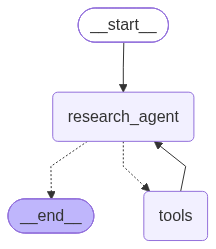

In [7]:
# ==========================================================
# Cell 6 : Visualize the LangGraph Workflow
# ==========================================================

from IPython.display import Image, display

# Display the graph
display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [8]:
# ==========================================================
# Cell 5 : Execute the Research Agent
# ==========================================================

user_query="Research on why sex is importent in humans"

result = app.invoke(

    {
        "messages": [

            SystemMessage(content=SYSTEM_PROMPT),

            HumanMessage(
                content=user_query,
            )

        ],

        "iteration": 0

    }

)

print("\n==============================")
print(" Final Answer")
print("==============================\n")

print(result["messages"][-1].content)


============ Iteration : 0 ==============

========== Agent Thinking ==========

🤖 Agent Response:


➡️ Routing to Tool

🔍 Web Search Tool Executed
Query: importance of sex in humans
============ Iteration : 1 ==============

========== Agent Thinking ==========

🤖 Agent Response:
Sex is important in humans for several reasons:

1. Reproduction: Sex is the primary method of reproduction in humans, allowing for the creation of a new generation and the continuation of the species.
2. Emotional Intimacy: Sex can bring people closer together, fostering emotional intimacy and bonding between partners.
3. Physical Health: Sex has been linked to several physical health benefits, including reduced stress, improved sleep, and increased immune function.
4. Mental Health: Sex can have a positive impact on mental health, reducing symptoms of anxiety and depression, and improving overall mood.
5. Relationship Satisfaction: Sex can play a significant role in relationship satisfaction, with a healthy